In [1]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


best_rf = joblib.load('models/random_forest_final.pkl')
X_test = joblib.load('data/X_test_fe.pkl')
y_test = joblib.load('data/y_test.pkl')

In [2]:
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]  # probability of class 1 (hazardous)

In [3]:
print(classification_report(y_test, y_pred, target_names=['Not Hazardous', 'Hazardous']))

               precision    recall  f1-score   support

Not Hazardous       0.98      0.94      0.96      7748
    Hazardous       0.47      0.78      0.59       508

     accuracy                           0.93      8256
    macro avg       0.73      0.86      0.78      8256
 weighted avg       0.95      0.93      0.94      8256



ROC-AUC Score: 0.9675


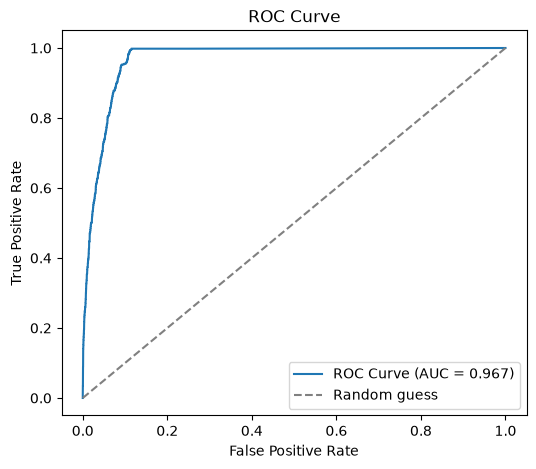

In [4]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

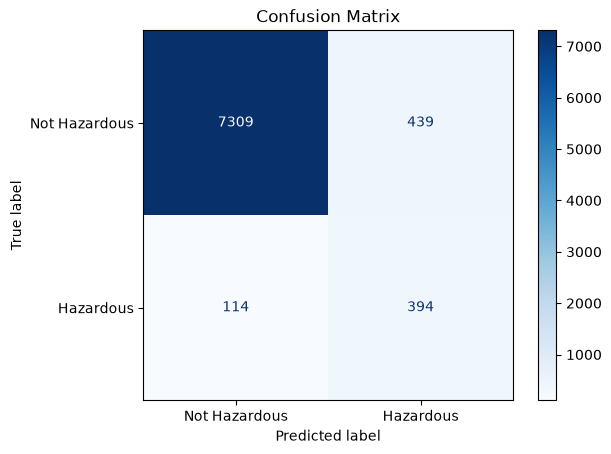

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hazardous', 'Hazardous'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

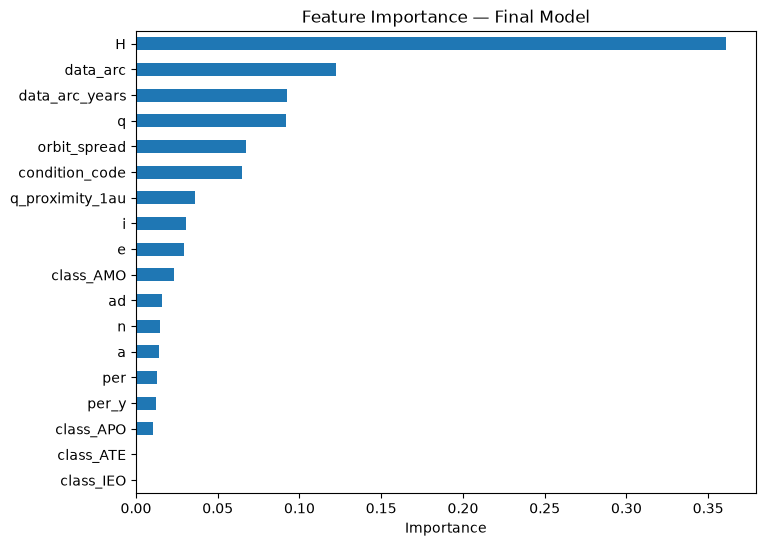

In [6]:
importances = pd.Series(best_rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance — Final Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [7]:
print(f"""
Final Model Evaluation Summary
--------------------------------
ROC-AUC: {auc_score:.4f}
Hazardous class Recall: see classification_report above
Total test samples: {len(y_test)}
Hazardous in test set: {y_test.sum()}
""")


Final Model Evaluation Summary
--------------------------------
ROC-AUC: 0.9675
Hazardous class Recall: see classification_report above
Total test samples: 8256
Hazardous in test set: 508

